In [ ]:
!pip install yfinance prophet plotly --quiet
!pip install tensorflow --quiet


In [ ]:
# ✅ Core libraries for data processing, plotting, and forecasting
!pip install --upgrade pip
!pip install yfinance
!pip install prophet
!pip install plotly
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install tensorflow
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


[*********************100%***********************]  1 of 1 completed


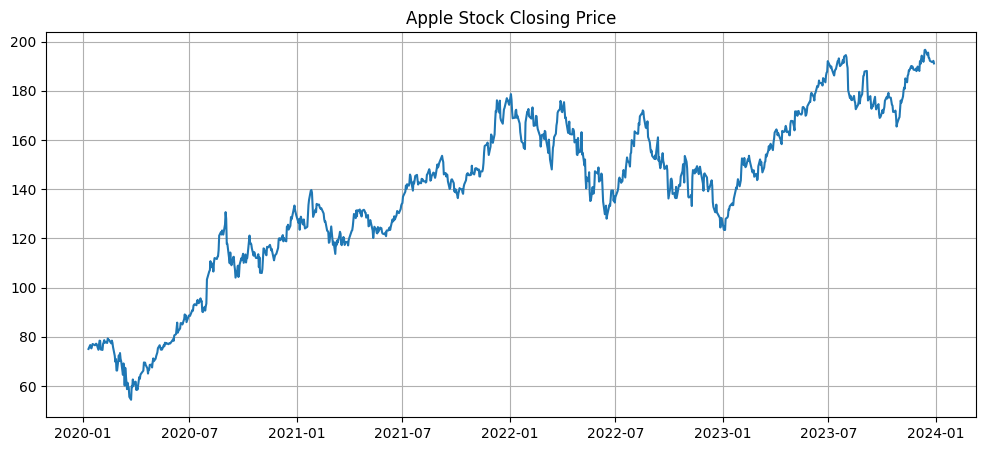

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Download ~10 years of daily Apple stock data (2500+ rows)
df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')

# Keep Date & Close only
df = df[['Close']]
df.reset_index(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.sort_index()

# Optional: Trim to last 1000 rows
df = df.tail(1000)

# Plot
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price")
plt.grid(True)
plt.show()




/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


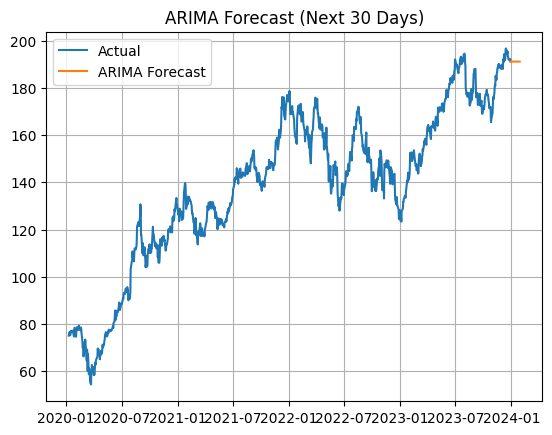

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Close'], order=(5,1,0))
model_fit = model.fit()

# Forecast next 30 days
forecast_arima = model_fit.forecast(steps=30)
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30)

arima_df = pd.DataFrame({'Date': future_dates, 'ARIMA_Forecast': forecast_arima.values})

# Plot
plt.plot(df['Close'], label='Actual')
plt.plot(arima_df['Date'], arima_df['ARIMA_Forecast'], label='ARIMA Forecast')
plt.title("ARIMA Forecast (Next 30 Days)")
plt.legend()
plt.grid(True)
plt.show()


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmph_tzjd7i/ytal0uki.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmph_tzjd7i/d0r73m2p.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79779', 'data', 'file=/tmp/tmph_tzjd7i/ytal0uki.json', 'init=/tmp/tmph_tzjd7i/d0r73m2p.json', 'output', 'file=/tmp/tmph_tzjd7i/prophet_model4w0csfj_/prophet_model-20250719061419.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:14:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:14:19 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


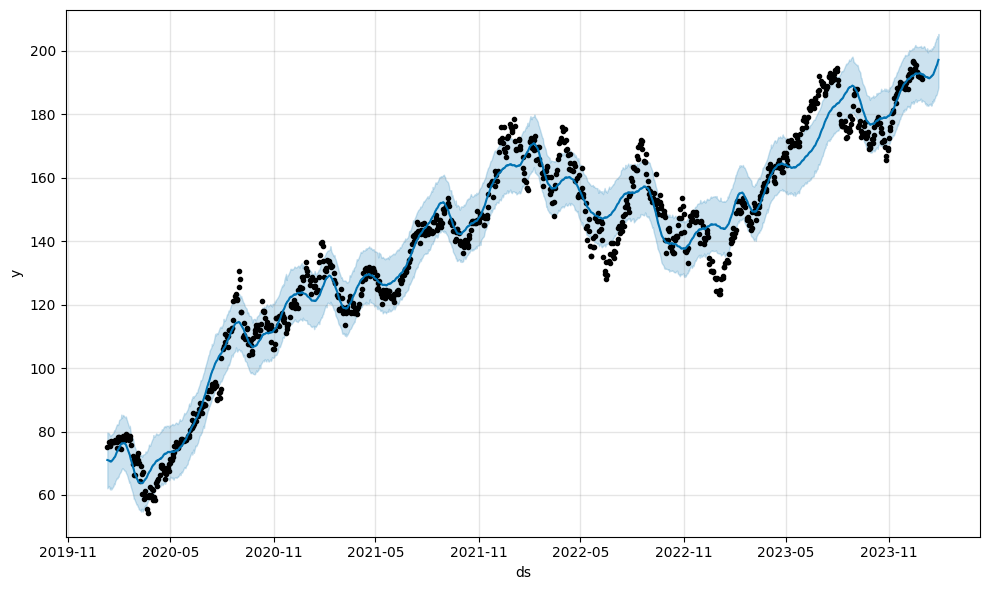

In [ ]:
from prophet import Prophet

# Prepare data
prophet_df = df.reset_index().copy()
prophet_df.columns = ['ds', 'y']  # Prophet needs ds and y

# Ensure datetime and numeric
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df['y'] = pd.to_numeric(prophet_df['y'], errors='coerce')

# Drop missing values
prophet_df.dropna(inplace=True)

# Fit the model
prophet = Prophet()
prophet.fit(prophet_df)

# Forecast future 30 days
future = prophet.make_future_dataframe(periods=30)
forecast = prophet.predict(future)

# Extract final forecast
forecast_df = forecast[['ds', 'yhat']].tail(30)
forecast_df.columns = ['Date', 'Prophet_Forecast']

# Plot
fig = prophet.plot(forecast)


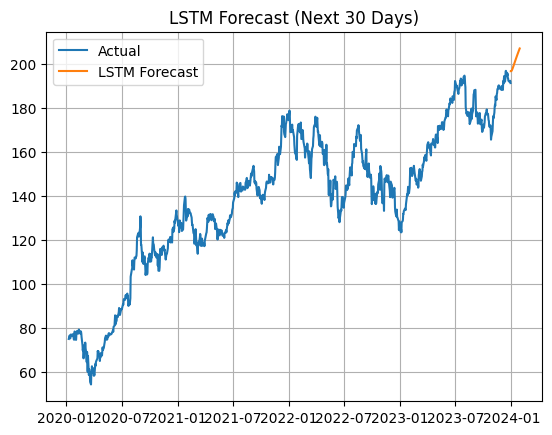

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close']])

# Create sequences
look_back = 60
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i])
    y.append(scaled_data[i])
X, y = np.array(X), np.array(y)

# Build LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32, verbose=0)

# Predict next 30 days
pred_input = scaled_data[-look_back:]
preds = []
for _ in range(30):
    input_reshaped = pred_input.reshape(1, look_back, 1)
    pred = model.predict(input_reshaped, verbose=0)[0][0]
    preds.append(pred)
    pred_input = np.append(pred_input[1:], [[pred]], axis=0)

# Inverse scale
preds = scaler.inverse_transform(np.array(preds).reshape(-1,1))
lstm_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30)
lstm_df = pd.DataFrame({'Date': lstm_dates, 'LSTM_Forecast': preds.flatten()})

# Plot
plt.plot(df['Close'], label='Actual')
plt.plot(lstm_df['Date'], lstm_df['LSTM_Forecast'], label='LSTM Forecast')
plt.title("LSTM Forecast (Next 30 Days)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
df.reset_index().to_csv('historical_data.csv', index=False)
arima_df.to_csv('arima_forecast.csv', index=False)
forecast_df.to_csv('prophet_forecast.csv', index=False)
lstm_df.to_csv('lstm_forecast.csv', index=False)

from google.colab import files
files.download('historical_data.csv')
files.download('arima_forecast.csv')
files.download('prophet_forecast.csv')
files.download('lstm_forecast.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install streamlit plotly pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.6 MB/s eta 0:00:00
